Instrumentos encontrados: ('ASRL4::INSTR',)
Instrumento conectado satisfactoriamente: GW,GDS-1102A-U,GES170725,V1.14
Escala vertical: 1.00 [V/div]


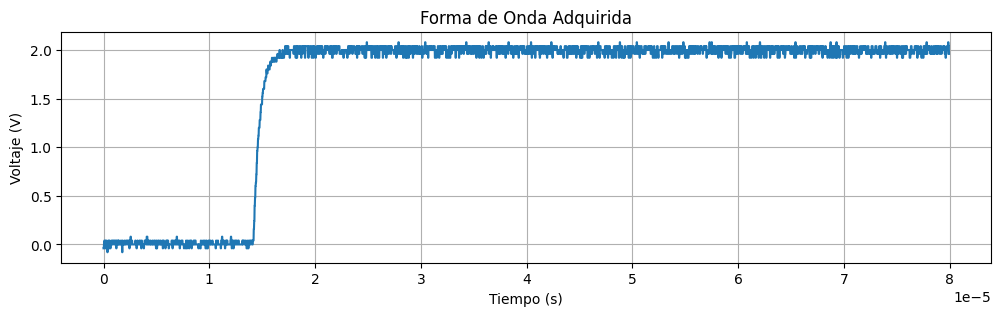

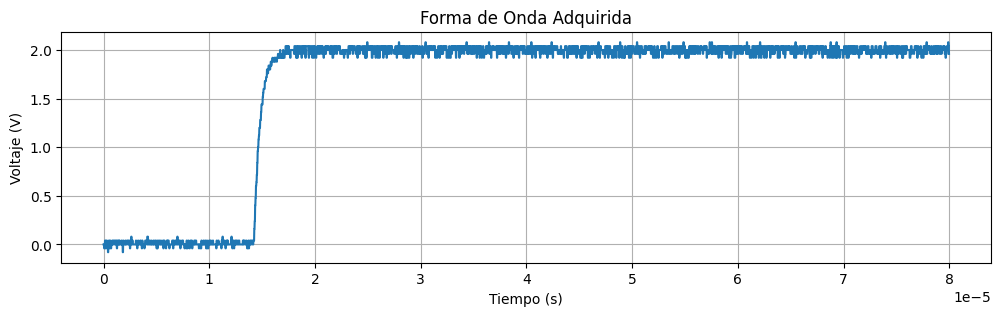

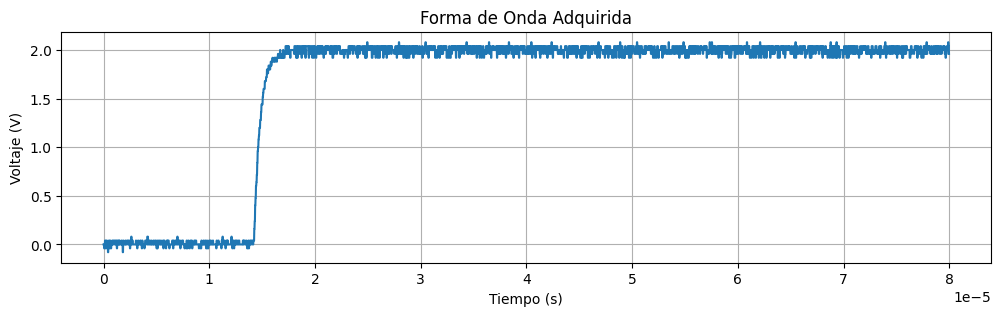

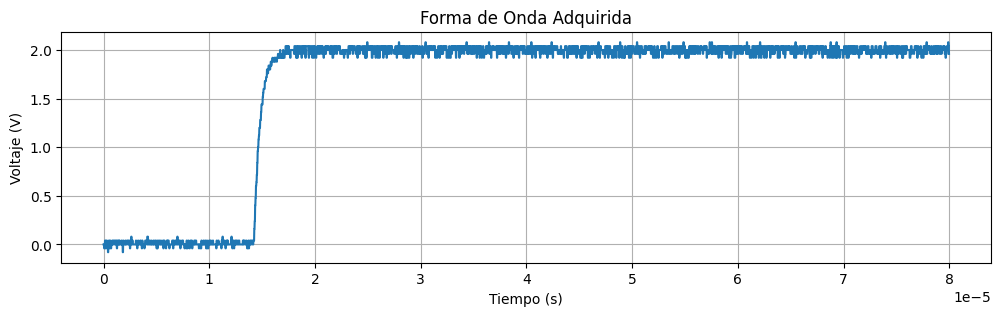

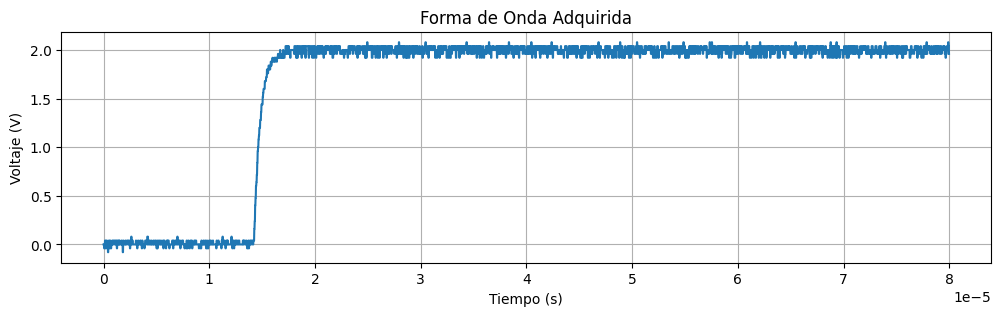

Conexión con el instrumento cerrada exitosamente.
Gestor de recursos cerrado exitosamente.


In [ ]:
import time
from struct import unpack
import sys
import pyvisa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py

def init_system():
    rm = pyvisa.ResourceManager()
    instrument_list = rm.list_resources()
    print("Instrumentos encontrados:", instrument_list)
    return rm

def init_instrument(manager, resource_name):
    try:
        dso = manager.open_resource(resource_name)
        dso.timeout = 5000
        dso.read_termination = '\n'
        dso.write_termination = '\n'
        idn = dso.query('*IDN?')
        print("Instrumento conectado satisfactoriamente:", idn)
    except Exception as e:
        print("Error al iniciar con el instrumento:", e)
        close_system()
    return dso

def close_instrument():
    try:
        dso.close()
        print("Conexión con el instrumento cerrada exitosamente.")
    except Exception as e:
        print("Error al cerrar la conexión con el instrumento:", e)

def close_system():
    try:
        close_instrument()
        resource_manager.close()
        print("Gestor de recursos cerrado exitosamente.")
    except Exception as e:
        print("Error al cerrar el gestor de recursos:", e)
        close_system()

def get_channel_scale(channel):
    try:
        scale = dso.query(f':channel{channel}:scale?')
        v_scale = float(scale)
        print(f'Escala vertical: {v_scale:.2f} [V/div]')
        return v_scale
    except Exception as e:
        print("Error al obtener la escala vertical:", e)
        close_system()

def read_bin():
    headerlen = 6
    vdiv = get_channel_scale(1)
    data = np.fromfile("datos_osciloscopio.bin", dtype=np.int8)
    waveform_raw = unpack('>%sh' % (int(len(data[headerlen + 8:]) / 2)), data[headerlen + 8:])
    num = len(waveform_raw)
    waveform = [0] * num
    for i in range(num):
        waveform[i] = waveform_raw[i] * vdiv / 25
    return waveform

def read_csv():
    df = pd.read_csv("datos_osciloscopio.csv")
    return df.values.flatten()

def read_npz():
    with np.load("datos_osciloscopio.npz") as f:
        return f['arr_0']

def read_h5():
    with h5py.File("datos_osciloscopio.h5", "r") as f:
        return f["ch1"][:]

def read_raw():
    data = np.fromfile("datos_osciloscopio.raw", dtype=np.float32)
    return data


def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (V)")
    plt.grid(True)
    plt.show()


if __name__ == '__main__':
    resource_manager = init_system()
    dso = init_instrument(resource_manager, 'ASRL4::INSTR')
    dt = 20e-9

    wave1 = read_bin()
    plot_waveform(wave1, dt)
    wave2 = read_csv()
    plot_waveform(wave2, dt)
    wave3 = read_npz()
    plot_waveform(wave3, dt)
    wave4 = read_h5()
    plot_waveform(wave4, dt)
    wave5 = read_raw()
    plot_waveform(wave5, dt)

    close_system()